In [ ]:
!pip install pandas numpy scikit-learn nltk spacy sentence-transformers textstat beautifulsoup4
!python -m spacy download en_core_web_sm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 177.1/177.1 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 21.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 82.3 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [ ]:
import pandas as pd
import numpy as np
import re
from bs4 import BeautifulSoup
from sklearn.metrics.pairwise import cosine_similarity
from sentence_transformers import SentenceTransformer
from sklearn.cluster import KMeans
import spacy
import textstat
from tqdm import tqdm

nlp = spacy.load("en_core_web_sm")
model = SentenceTransformer('all-MiniLM-L6-v2')

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [ ]:
import pandas as pd

# Load dataset
df = pd.read_excel("/content/drive/MyDrive/newmanproject/data/NewsSumm Dataset.xlsx")

print("Columns in dataset:", df.columns)

# Try to auto-detect columns
possible_article_cols = ['article', 'news', 'text', 'document', 'content']
possible_summary_cols = ['summary', 'summ', 'headline', 'title']

article_col = None
summary_col = None

for col in df.columns:
    if col.lower() in possible_article_cols:
        article_col = col
    if col.lower() in possible_summary_cols:
        summary_col = col

# If not detected, manually assign here 👇
if article_col is None or summary_col is None:
    print("⚠️ Could not auto-detect columns. Please assign manually.")
    print(df.head())
else:
    print("Detected Article Column:", article_col)
    print("Detected Summary Column:", summary_col)

Columns in dataset: Index(['newspaper_name', 'published_date\n', 'headline', 'article_text',
       'human_summary', 'news_category'],
      dtype='object')
⚠️ Could not auto-detect columns. Please assign manually.
      newspaper_name     published_date\n  \
0     Indian Express  2020-06-01 00:00:00   
1     Economic Times  2013-02-11 00:00:00   
2  Business Standard  2013-02-11 00:00:00   
3      Money Control  2013-02-11 00:00:00   
4           The Mint  2023-10-02 00:00:00   

                                            headline  \
0  Virus may be invisible enemy but COVID warrior...   
1              Economy can bounce back, says PM Modi   
2        At least 20 killed in stampede in Allahabad   
3  Maha Kumbh: Over 20 dead in Allahabad station ...   
4                                    Gandhian wisdom   

                                        article_text  \
0  Prime Minister Narendra Modi Monday hailed the...   
1  ALLAHABAD: At least 20 persons were killed, an...   
2  At lea

In [ ]:
import re
from bs4 import BeautifulSoup

# Manual assignment of columns based on dataset output from previous cell if auto-detection failed
if 'article_col' not in locals() or article_col is None:
    article_col = 'article_text'
if 'summary_col' not in locals() or summary_col is None:
    summary_col = 'headline' # Or 'human_summary' if preferred for actual summaries

df = df[[article_col, summary_col]].dropna().reset_index(drop=True)

def clean_text(text):
    text = BeautifulSoup(str(text), "html.parser").get_text()
    text = re.sub(r"http\S+", "", text)
    text = re.sub(r"[^a-zA-Z0-9.,!? ]+", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text.lower()

df['clean_article'] = df[article_col].apply(clean_text)
df['clean_summary'] = df[summary_col].apply(clean_text)

print("After cleaning:", len(df))

/tmp/ipykernel_5467/1221643058.py:13: MarkupResemblesLocatorWarning: The input passed in on this line looks more like a URL than HTML or XML.

If you meant to use Beautiful Soup to parse the web page found at a certain URL, then something has gone wrong. You should use an Python package like 'requests' to fetch the content behind the URL. Once you have the content as a string, you can feed that string into Beautiful Soup.

However, if you want to parse some data that happens to look like a URL, then nothing has gone wrong: you are using Beautiful Soup correctly, and this warning is spurious and can be filtered. To make this warning go away, run this code before calling the BeautifulSoup constructor:

    from bs4 import MarkupResemblesLocatorWarning
    import warnings

    warnings.filterwarnings("ignore", category=MarkupResemblesLocatorWarning)
    
  text = BeautifulSoup(str(text), "html.parser").get_text()
/tmp/ipykernel_5467/1221643058.py:13: MarkupResemblesLocatorWarning: The inp

After cleaning: 348739


In [ ]:
!pip install faiss-cpu

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.8/23.8 MB 19.7 MB/s eta 0:00:00


In [ ]:
import faiss
import numpy as np
from sentence_transformers import SentenceTransformer

# Load model
model = SentenceTransformer('all-MiniLM-L6-v2')

# Generate embeddings
embeddings = model.encode(
    df['clean_article'].tolist(),
    batch_size=64,
    show_progress_bar=True
)

# Convert to numpy float32
embeddings = np.array(embeddings).astype("float32")

# Normalize (IMPORTANT for cosine similarity)
faiss.normalize_L2(embeddings)

# Build FAISS index
index = faiss.IndexFlatIP(embeddings.shape[1])  # inner product = cosine
index.add(embeddings)

# Search nearest neighbors (k=2 because first is itself)
k = 2
distances, indices = index.search(embeddings, k)

to_remove = set()

for i in range(len(indices)):
    for j in range(1, k):  # skip itself
        if distances[i][j] > 0.90:
            to_remove.add(indices[i][j])

# Remove duplicates
df = df.drop(list(to_remove)).reset_index(drop=True)

print("After fast duplicate removal:", len(df))

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Batches:   0%|          | 0/5450 [00:00<?, ?it/s]

After fast duplicate removal: 291872


In [ ]:
def quality_check(row):
    article_len = len(row['clean_article'].split())
    summary_len = len(row['clean_summary'].split())

    if summary_len < 8:
        return False
    if summary_len > article_len:
        return False
    if summary_len / article_len < 0.08:
        return False
    return True

df = df[df.apply(quality_check, axis=1)].reset_index(drop=True)

print("After quality filtering:", len(df))

After quality filtering: 45373


In [ ]:
# 🔍 Check available columns
print("Available columns:", df.columns)

Available columns: Index(['article_text', 'headline', 'clean_article', 'clean_summary',
       'article_len', 'summary_len'],
      dtype='object')


In [ ]:
import spacy
import textstat
import pandas as pd

nlp = spacy.load("en_core_web_sm")

def extract_features(text):
    doc = nlp(text)
    words = text.split()

    return {
        "token_count": len(words),
        "sentence_count": len(list(doc.sents)),
        "entity_count": len(doc.ents),
        "readability": textstat.flesch_reading_ease(text),
        "lexical_diversity": len(set(words)) / len(words) if len(words) > 0 else 0
    }

features = df['clean_article'].apply(extract_features)
features_df = pd.json_normalize(features)

df = pd.concat([df, features_df], axis=1)

print("✅ Feature extraction done")

✅ Feature extraction done


In [ ]:
from sklearn.cluster import MiniBatchKMeans

# Use embeddings from previous FAISS step
k = max(10, len(df) // 100)   # adaptive clusters

kmeans = MiniBatchKMeans(n_clusters=k, batch_size=1024, random_state=42)
df['cluster_id'] = kmeans.fit_predict(embeddings[:len(df)])

print("✅ Clustering done")
print("Total clusters:", df['cluster_id'].nunique())

✅ Clustering done
Total clusters: 453


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans

# Convert text to vectors
vectorizer = TfidfVectorizer(max_features=5000, stop_words='english')
X = vectorizer.fit_transform(df['clean_article'])

# Choose number of categories
k = 6

kmeans = KMeans(n_clusters=k, random_state=42)
df['new_category'] = kmeans.fit_predict(X)

print("✅ ML-based categories created")
print(df['new_category'].value_counts())

✅ ML-based categories created
new_category
1    21190
3     8433
0     6055
2     4767
5     2810
4     2118
Name: count, dtype: int64


In [ ]:
# Safe sorting (cluster-wise grouping)
df = df.sort_values(by=['cluster_id', 'new_category'])

print("✅ Structured ordering applied (cluster + category)")

✅ Structured ordering applied (cluster + category)


In [ ]:
df = df.sort_values(by=['cluster_id', 'article_len'])

print("✅ Pseudo-temporal ordering applied")

✅ Pseudo-temporal ordering applied


In [ ]:
# Final structured ordering
df = df.sort_values(by=['cluster_id', 'new_category', 'article_len'])

print("✅ Final dataset structured successfully")

✅ Final dataset structured successfully


In [ ]:


# Sort inside clusters
df = df.sort_values(by=['cluster_id', 'new_category'])

print("✅ Temporal ordering done")

✅ Temporal ordering done


In [ ]:
cluster_sizes = df['cluster_id'].value_counts()

# Keep clusters with at least 3 articles
valid_clusters = cluster_sizes[cluster_sizes >= 3].index

df = df[df['cluster_id'].isin(valid_clusters)].reset_index(drop=True)

print("After cluster filtering:", len(df))

After cluster filtering: 45284


In [ ]:
agg_dict = {
    'clean_article': list,
    'clean_summary': list
}

# Add optional columns ONLY if they exist
if 'headline' in df.columns:
    agg_dict['headline'] = list

if 'new_category' in df.columns:
    agg_dict['new_category'] = 'first'

if 'published_date' in df.columns:
    agg_dict['published_date'] = list

# Group safely
grouped = df.groupby('cluster_id').agg(agg_dict).reset_index()

# Rename for multi-doc format
grouped.rename(columns={
    'clean_article': 'documents',
    'clean_summary': 'summaries'
}, inplace=True)

print("✅ Multi-document dataset created successfully")
print("Total clusters (final):", len(grouped))

✅ Multi-document dataset created successfully
Total clusters (final): 387


In [ ]:
# Save both versions

# 1. Flat dataset
df.to_csv("NewsSumm_PP_flat.csv", index=False)

# 2. Multi-document dataset (IMPORTANT for paper)
grouped.to_json("NewsSumm_PP_multidoc.json", orient="records", indent=2)

print("🎉 NewsSumm++ dataset READY!")

🎉 NewsSumm++ dataset READY!


/tmp/ipykernel_5467/2156500841.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y='new_category', data=df, order=df['new_category'].value_counts().index, palette='viridis')


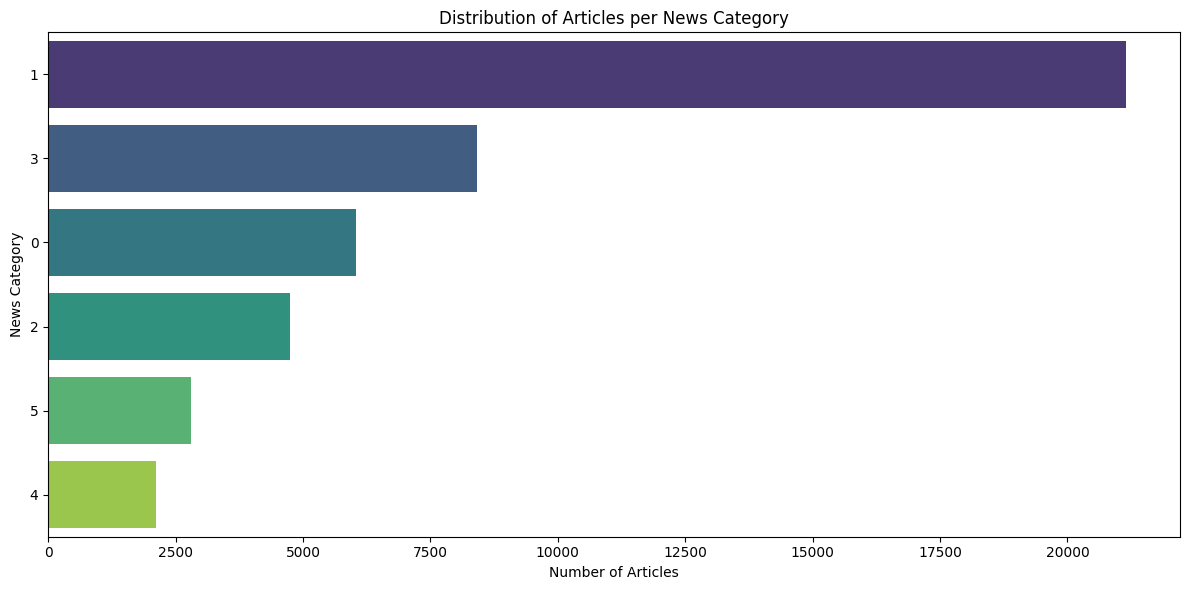

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))
sns.countplot(y='new_category', data=df, order=df['new_category'].value_counts().index, palette='viridis')
plt.title('Distribution of Articles per News Category')
plt.xlabel('Number of Articles')
plt.ylabel('News Category')
plt.tight_layout()
plt.show()

In [ ]:
category_percentage = df['new_category'].value_counts(normalize=True) * 100
print("Percentage Distribution of Articles per Category:")
print(category_percentage)

Percentage Distribution of Articles per Category:
new_category
1    46.705238
3    18.593764
0    13.340253
2    10.498189
5     6.192033
4     4.670524
Name: proportion, dtype: float64
